# Assignment 4 : Multigrid method

In [2]:
import numpy as np
import matplotlib.pyplot as plt

## Question 1

In [4]:
def Poisson2D(n):
    h = 1.0 / (n + 1)

    T = 2*np.eye(n) - np.eye(n, k=1) - np.eye(n, k=-1)

    I = np.eye(n)

    A = (np.kron(I, T) + np.kron(T, I)) / (h**2)

    return A

## Question 2

In [6]:
def weighted_jacobi(A, u, f, num_iter=2):
    D_inv = 1.0 / A.diagonal()
    
    for _ in range(num_iter):
        u = u + (2/3) * D_inv * (f - A@u)
    
    return u 

In [7]:
def restrict(A, direct_N):
    A_list = []
    R_list = []
    
    level = 0
    A_list.append(A)
    N = A.shape[0]
    n = int(np.sqrt(N))
    
    while N > direct_N:
        nc = (n - 1) // 2
        Nc = nc ** 2
        R = np.zeros((Nc,N))
        kc = 0
        for jc in range(1, nc+1):
            for ic in range(1, nc+1):
                i = 2*ic
                j = 2*jc
                kf = (j-1)*n + i - 1
                R[kc, kf-n-1] = 1/16
                R[kc, kf-n] = 1/8
                R[kc, kf-n+1] = 1/16
    
                R[kc, kf-1] = 1/8
                R[kc, kf] = 1/4
                R[kc, kf+1] = 1/8
    
                R[kc, kf+n-1] = 1/16
                R[kc, kf+n] = 1/8
                R[kc, kf+n+1] = 1/16
                
                kc += 1
        R_list.append(R)
        P = 4*R.transpose()
        A = R@A@P
        level += 1
        A_list.append(A)
        n=nc
        N = Nc
    
    max_level = level
    return A_list, R_list, max_level

In [8]:
def vcycle(level, A_list, R_list, b, x0, direct_n, weight = 4, pre_smooth=2, post_smooth=2):
    A = A_list[level]
    
    n = len(b)
    # If the system is small enough
    if level == len(R_list):
        x = np.linalg.solve(A, b)
        return x

    # Pre-smoothing
    x = weighted_jacobi(A, x0, b, pre_smooth)
    
    # Compute the residual
    r = b - A@x
    
    # Restrict the residual to a coarse grid
    R = R_list[level]
    r_H = R@r
    coarse_n = len(r_H)
    e0 = np.zeros(coarse_n)
    
    # Recursive V-cycle
    e = vcycle(level + 1, A_list, R_list, r_H, e0, direct_n, weight, pre_smooth, post_smooth)
    
    # Interpolate back to the fine grid and correct the solution
    P = weight * R.transpose()
    e_fine = P@e
    x = x + e_fine
    
    # Post-smoothing
    x = weighted_jacobi(A, x, b, post_smooth)
    return x

## Question 3

In [10]:
p = 5
n = 2**p - 1
f = np.random.rand(n**2)

In [11]:
u = np.zeros(n**2)

A = Poisson2D(n)

residual_norms = []

r0 = f - A@u
residual_norms.append(np.linalg.norm(r0, 2))

A_list, R_list, max_level = restrict(A, n)

In [12]:
for k in range(15):
    u = vcycle(0, A_list, R_list, f, u, 3)
    
    r = f - A@u
    residual_norms.append(np.linalg.norm(r, 2))

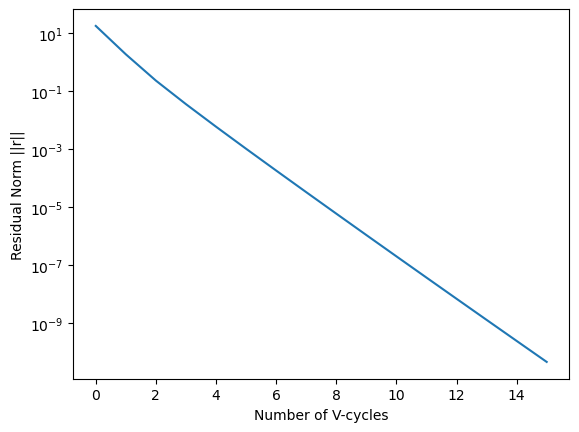

In [13]:
plt.plot(residual_norms)
plt.xlabel('Number of V-cycles')
plt.ylabel('Residual Norm ||r||')
plt.yscale('log')
plt.show()

On a semi-logarithmic plot, a straight line decrease of the residual norms indicates exponential convergence of the method.

This behavior is characteristic of an efficient multigrid solver:

- the convergence rate is independent (or weakly dependent) on the grid size,
- both high-frequency and low-frequency errors are effectively reduced within each V-cycle.

The slope of the line corresponds to the convergence factor: a steeper slope means faster convergence.